In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

import pickle


In [7]:
df = pd.read_csv("Electric_Vehicle_Population_Data.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
df.info()

print("\nStatistical Summary:")
print(df.describe())

First 5 rows:
   VIN (1-10)    County               City State  Postal Code  Model Year  \
0  1N4AZ0CP6D      King           Kirkland    WA      98034.0        2013   
1  5YJ3E1EC8L    Kitsap  Bainbridge Island    WA      98110.0        2020   
2  5YJ3E1EBXJ      King            Seattle    WA      98144.0        2018   
3  ZFAFFAC45R  Thurston               Yelm    WA      98597.0        2024   
4  5YJYGDEE3L      King               Kent    WA      98030.0        2020   

     Make    Model           Electric Vehicle Type  \
0  NISSAN     LEAF  Battery Electric Vehicle (BEV)   
1   TESLA  MODEL 3  Battery Electric Vehicle (BEV)   
2   TESLA  MODEL 3  Battery Electric Vehicle (BEV)   
3    FIAT     500E  Battery Electric Vehicle (BEV)   
4   TESLA  MODEL Y  Battery Electric Vehicle (BEV)   

   Clean Alternative Fuel Vehicle (CAFV) Eligibility  Electric Range  \
0            Clean Alternative Fuel Vehicle Eligible            75.0   
1            Clean Alternative Fuel Vehicle Eligible  

In [8]:
# Remove missing values
df = df.dropna()

# Remove duplicates
df = df.drop_duplicates()

# Remove invalid electric range values
df = df[df['Electric Range'] > 0]

print("Cleaned Data Shape:", df.shape)

Cleaned Data Shape: (100992, 16)


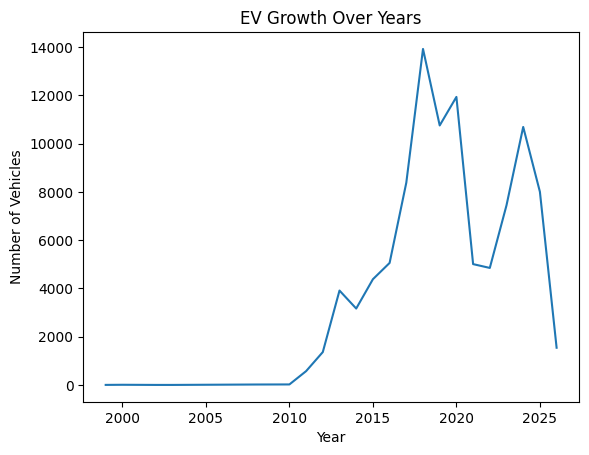

In [9]:
plt.figure()
df['Model Year'].value_counts().sort_index().plot(kind='line')
plt.title("EV Growth Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Vehicles")
plt.show()

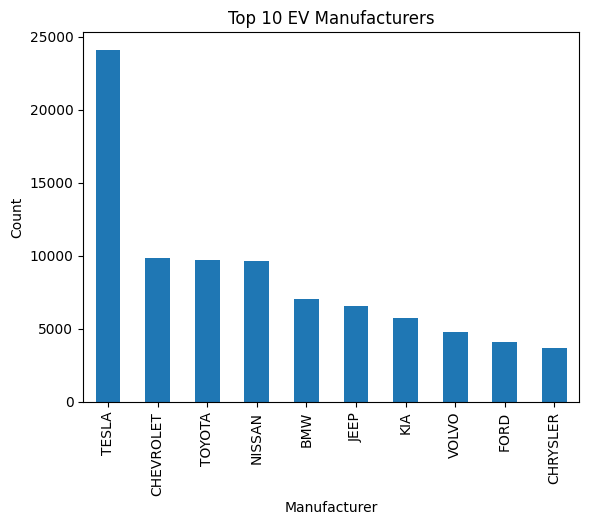

In [10]:
plt.figure()
df['Make'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 EV Manufacturers")
plt.xlabel("Manufacturer")
plt.ylabel("Count")
plt.show()

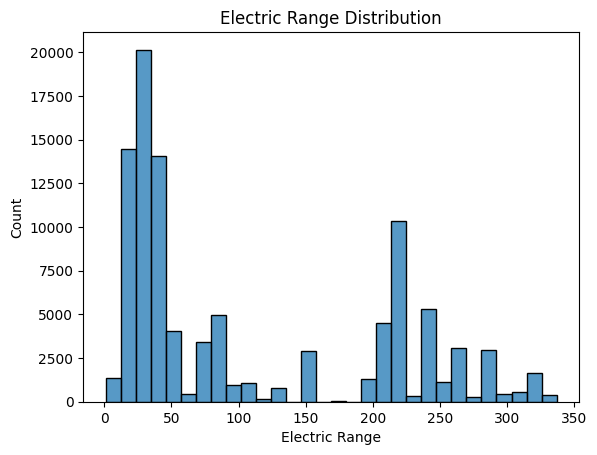

In [11]:
plt.figure()
sns.histplot(df['Electric Range'], bins=30)
plt.title("Electric Range Distribution")
plt.show()

In [12]:
features = ['Make', 'Model Year', 'Electric Vehicle Type']
target = 'Electric Range'

X = df[features]
y = df[target]

In [13]:
le_make = LabelEncoder()
le_type = LabelEncoder()

X['Make'] = le_make.fit_transform(X['Make'])
X['Electric Vehicle Type'] = le_type.fit_transform(X['Electric Vehicle Type'])

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

Training data size: (80793, 3)
Testing data size: (20199, 3)


In [15]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

In [16]:
print("Linear Regression Results:")
print("MAE:", mean_absolute_error(y_test, lr_pred))
print("R2 Score:", r2_score(y_test, lr_pred))

Linear Regression Results:
MAE: 33.56854204421012
R2 Score: 0.7723359259656282


In [17]:
rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [18]:
print("\nRandom Forest Results:")
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("R2 Score:", r2_score(y_test, rf_pred))


Random Forest Results:
MAE: 4.5761647680834825
R2 Score: 0.9874868751057858


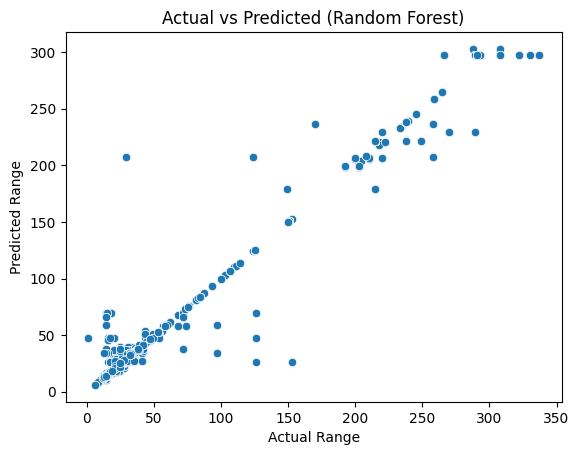

In [19]:
plt.figure()
sns.scatterplot(x=y_test, y=rf_pred)
plt.xlabel("Actual Range")
plt.ylabel("Predicted Range")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

In [20]:
with open("model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

print("Model saved successfully!")

Model saved successfully!
